<a href="https://colab.research.google.com/github/padhab34-bit/IML/blob/main/shakespeare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
!pip install requests

In [3]:
import requests

target_url ='https://www.gutenberg.org/files/2265/2265-0.txt'

response = requests.get(target_url)

data = response.text

In [4]:
!pip install TextBlob
from textblob import TextBlob
blob=TextBlob(data)

In [5]:
import imageio.v3 as iio

image_file="https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"

mask_image = iio.imread(image_file)

In [14]:
from nltk.corpus import stopwords
import collections

# Get words from TextBlob, convert to lowercase
all_words = [word.lower() for word in blob.words]

# Filter stopwords and non-alphabetic words
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in all_words if word.isalpha() and word not in stop_words]

# Count word frequencies
word_counts = collections.Counter(filtered_words)

print(f"Total unique words after filtering: {len(word_counts)}")
print("Top 20 words:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

Total unique words after filtering: 4585
Top 20 words:
ham: 337
lord: 211
haue: 175
king: 173
shall: 107
come: 106
thou: 105
let: 104
hamlet: 100
good: 98
hor: 95
thy: 90
enter: 85
oh: 81
like: 78
well: 70
may: 69
know: 69
selfe: 68
would: 68


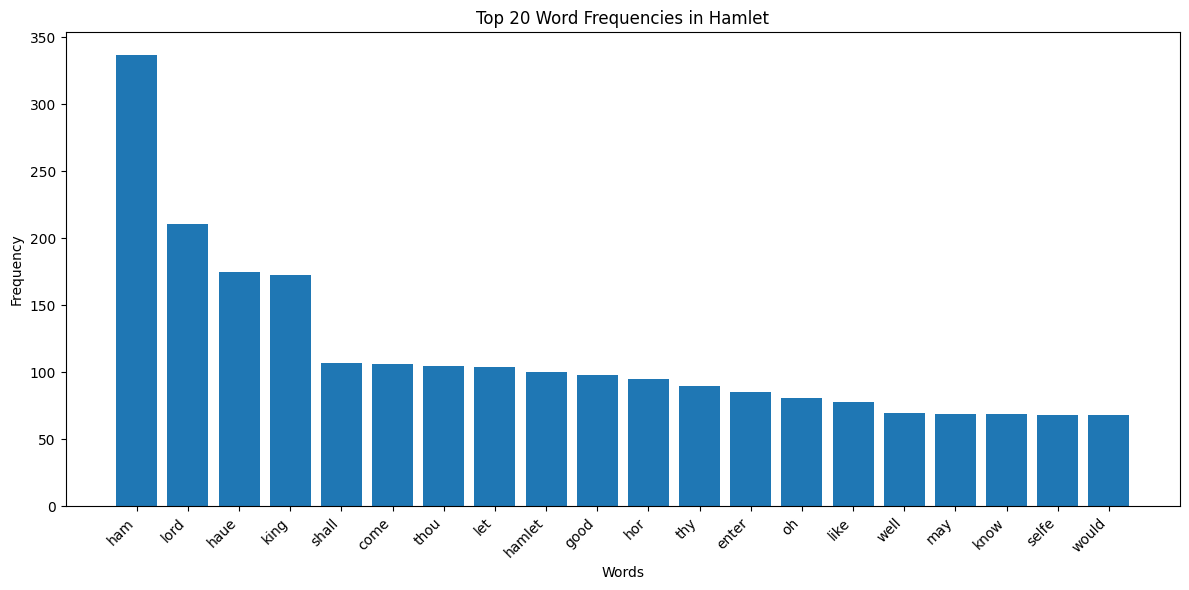

In [15]:
import matplotlib.pyplot as plt

# Get top 20 words and their counts
top_20_words = word_counts.most_common(20)
words = [word for word, count in top_20_words]
counts = [count for word, count in top_20_words]

# Create bar chart
plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Word Frequencies in Hamlet')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Now, let's generate the word cloud.

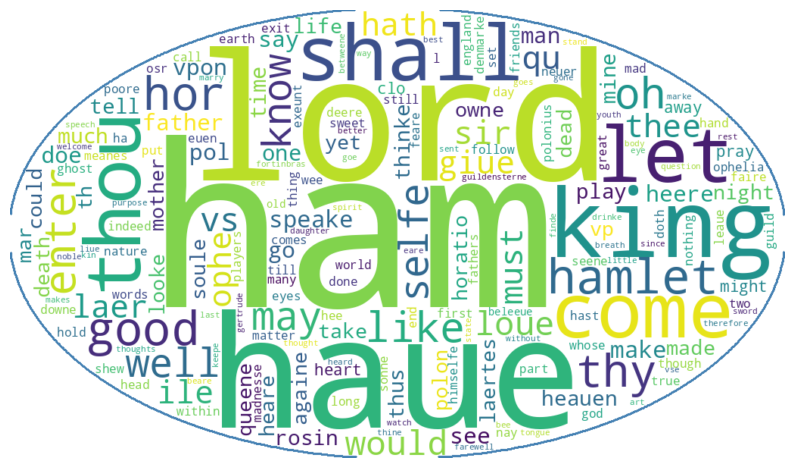

In [18]:
from wordcloud import WordCloud
import numpy as np
import matplotlib.pyplot as plt



if mask_image.shape[2] == 4:

    processed_mask = mask_image[:, :, 3]
else:

    gray_mask = mask_image.mean(axis=2).astype(np.uint8)

    processed_mask = gray_mask

# Create a WordCloud object
wordcloud = WordCloud(
    width=1000,
    height=1000,
    background_color='white',
    mask=processed_mask,
    contour_width=3,
    contour_color='steelblue'
)

# Generate a word cloud from the frequency dictionary
wordcloud.generate_from_frequencies(word_counts)

# Display the generated image:
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()